In [2]:
!pip3 install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 81.8 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 111.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]er]


# Расчет параметров на старте движения в точке H_S=15км - переход с 100км на 15км. 

In [2]:
import numpy as np

# --- Константы ---
MU_MOON = 4.9048695e12    # Гравитационный параметр Луны, м^3/с^2
R_MOON = 1737400.0        # Радиус Луны, м
M_INITIAL = 15000.0       # Масса КА на орбите 100 км, кг
ISP = 311.0               # Удельный импульс двигателя, с
G0 = 9.80665              # Стандартное ускорение, м/с^2

# --- Высоты ---
H0 = 100000.0             # Опорная орбита 100 км
Hp = 15000.0              # Перицентр (начало спуска) 15 км

# Радиусы от центра Луны
r_apo = R_MOON + H0       # Радиус апоцентра
r_peri = R_MOON + Hp      # Радиус перицентра

# ==========================================
# ЭТАП 1: Круговая орбита 100 км
# ==========================================
# Для круговой орбиты r = a
V_circ_100 = np.sqrt(MU_MOON / r_apo)

# ==========================================
# ЭТАП 2: Переходный эллипс (100 км х 15 км)
# ==========================================
# Большая полуось эллипса
a_ellipse = (r_apo + r_peri) / 2.0

# Скорость в апоцентре (100 км), необходимая для перехода на эллипс
V_apo_ellipse = np.sqrt(MU_MOON * (2.0 / r_apo - 1.0 / a_ellipse))

# Требуемый тормозной импульс (Delta V) для схода с орбиты
Delta_V_DOI = V_circ_100 - V_apo_ellipse

# ==========================================
# ЭТАП 3: Расход топлива (Уравнение Циолковского)
# ==========================================
# M_final = M_initial * exp(-DeltaV / (Isp * g0))
M_after_DOI = M_INITIAL * np.exp(-Delta_V_DOI / (ISP * G0))
Fuel_spent_DOI = M_INITIAL - M_after_DOI

# ==========================================
# ЭТАП 4: Скорость в перицентре (15 км)
# ==========================================
# Это и есть та самая начальная скорость для нашей глиссады!
V_peri_ellipse = np.sqrt(MU_MOON * (2.0 / r_peri - 1.0 / a_ellipse))

# --- ВЫВОД РЕЗУЛЬТАТОВ ---
print("=== РАСЧЕТ ПЕРЕХОДА С ОКОЛОЛУННОЙ ОРБИТЫ НА ТРАЕКТОРИЮ СПУСКА ===")
print(f"1. Скорость на круговой орбите (100 км): {V_circ_100:.2f} м/с")
print(f"2. Скорость после выдачи импульса (100 км): {V_apo_ellipse:.2f} м/с")
print(f"3. Тормозной импульс для схода (Delta V): {Delta_V_DOI:.2f} м/с")
print(f"4. Потрачено топлива на маневр: {Fuel_spent_DOI:.2f} кг")
print(f"5. Масса аппарата перед началом торможения (на 15 км): {M_after_DOI:.2f} кг\n")

print("=== ИСХОДНЫЕ ДАННЫЕ ДЛЯ БАЛЛИСТИЧЕСКОЙ ГЛИССАДЫ (на H = 15 км) ===")
print(f"Вектор X (Высота): {Hp} м")
print(f"Вектор Vx (Горизонтальная скорость): {V_peri_ellipse:.2f} м/с !!!")
print(f"Вектор Vy (Вертикальная скорость): 0.00 м/с (в перицентре скорость строго горизонтальна)")
print(f"Масса КА (M0): {M_after_DOI:.2f} кг")


=== РАСЧЕТ ПЕРЕХОДА С ОКОЛОЛУННОЙ ОРБИТЫ НА ТРАЕКТОРИЮ СПУСКА ===
1. Скорость на круговой орбите (100 км): 1633.85 м/с
2. Скорость после выдачи импульса (100 км): 1614.39 м/с
3. Тормозной импульс для схода (Delta V): 19.46 м/с
4. Потрачено топлива на маневр: 95.40 кг
5. Масса аппарата перед началом торможения (на 15 км): 14904.60 кг

=== ИСХОДНЫЕ ДАННЫЕ ДЛЯ БАЛЛИСТИЧЕСКОЙ ГЛИССАДЫ (на H = 15 км) ===
Вектор X (Высота): 15000.0 м
Вектор Vx (Горизонтальная скорость): 1692.70 м/с !!!
Вектор Vy (Вертикальная скорость): 0.00 м/с (в перицентре скорость строго горизонтальна)
Масса КА (M0): 14904.60 кг


--- РЕАЛИСТИЧНЫЕ ПАРАМЕТРЫ ДЛЯ ПЕРЕДАЧИ В ИИ (Hs = 2000.0 м) ---
Время: 467.1 с
Дальность X: 428.01 км
Высота Y (H_C): 1970.6 м
Гориз. скорость Vx: 0.0 м/с  <-- ВОТ ЭТО УЖЕ ОТЛИЧНО!
Верт. скорость Vy: -38.4 м/с
Масса КА: 8110.2 кг
Топлива потрачено: 6889.8 кг
Остаток топлива на посадку: 3110.2 кг (предполагая 5000 кг - сухая масса)
Угол наклона тяги к горизонту: 10.9 градусов


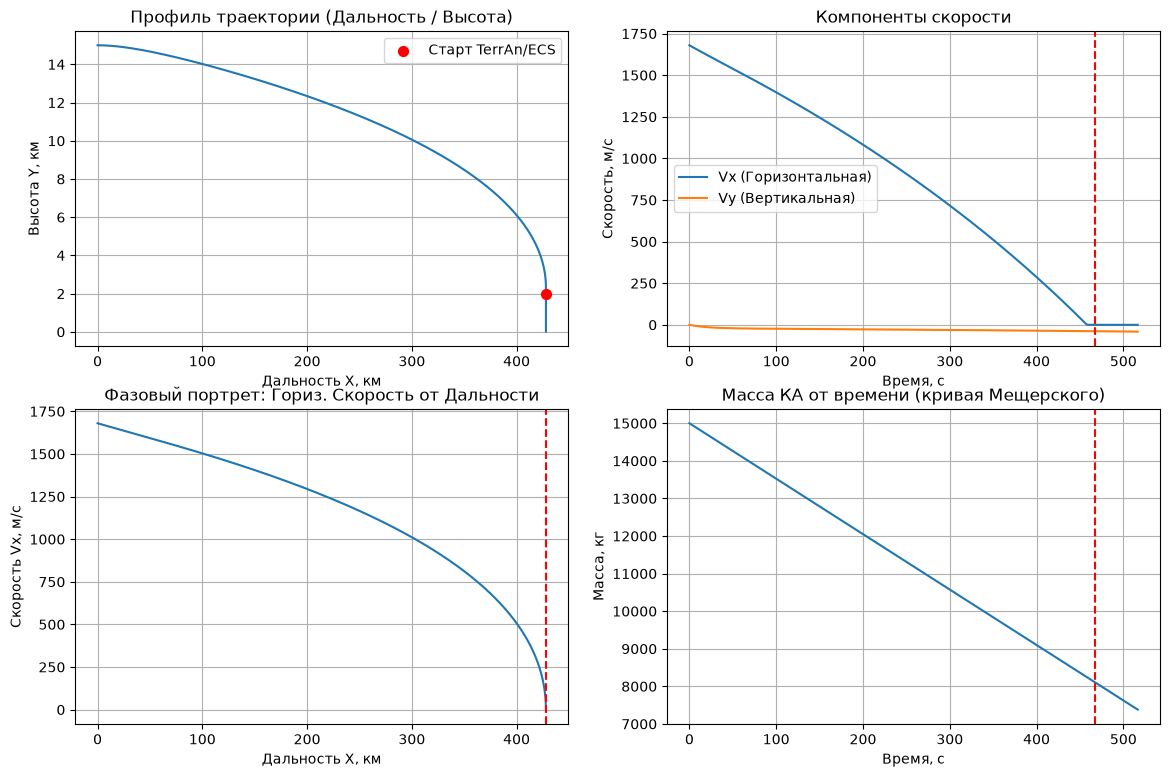

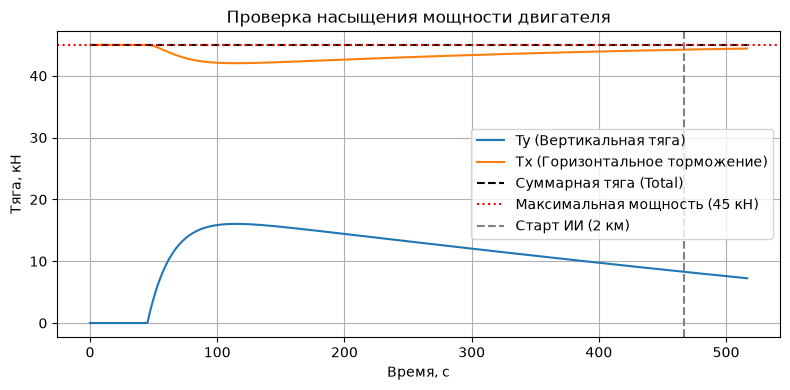

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Константы ---
G_MOON = 1.62        
M0 = 15000.0         
THRUST = 45000.0     
ISP = 311.0          
G0 = 9.81            
MASS_FLOW = THRUST / (ISP * G0) 

# --- Начальные условия (15 км) ---
Y0 = 15000.0         
X0 = 0.0             
VX0 = 1680.0         
VY0 = 0.0            

# Измененный закон управления (Guidance Law)
def lander_dynamics(t, state):
    x, y, vx, vy, m = state
    
    # 1. НОВАЯ ГЛИССАДА:
    # Заставляем аппарат начать снижение сразу со скоростью -25 м/с.
    # К поверхности скорость спуска плавно возрастет до -45 м/с.
    # vy_desired = -25.0 - 20.0 * (1.0 - y / 15000.0) 
    vy_desired = -22.0 - 20.0 * (1.0 - y / 15000.0) 

    # 2. П-регулятор
    Kp = 0.05
    ay_desired = Kp * (vy_desired - vy)
    
    # 3. Вертикальная тяга с компенсацией гравитации
    Ty = m * (ay_desired + G_MOON)
    
    # Жестко ограничиваем Ty, чтобы не выйти за пределы возможностей двигателя
    Ty = np.clip(Ty, 0, THRUST)
        
    # 4. Всю оставшуюся тягу пускаем на торможение по горизонтали
    # max(0, ...) защищает от ошибки вычисления корня отрицательного числа (float precision)
    Tx_max = np.sqrt(max(0, THRUST**2 - Ty**2))
    
    # Плавное гашение горизонтальной скорости
    if vx > 5.0:
        Tx = -Tx_max
    elif vx > 0.0:
        Tx = -Tx_max * (vx / 5.0) # Плавно сбрасываем тягу перед полной остановкой
    else:
        Tx = 0 
        
    # 5. Ускорения
    ax = Tx / m
    ay = (Ty / m) - G_MOON
    
    dm_dt = -MASS_FLOW
    
    # Ограничение по массе (если топливо кончится, тяга пропадает)
    if m < 5000.0: # ~5000 кг - сухая масса КА
        ax = 0
        ay = -G_MOON
        dm_dt = 0
    
    return [vx, vy, ax, ay, dm_dt]

# Остановка симуляции
def hit_ground(t, state):
    return state[1] - 10 # Остановим на 10 метрах от земли
hit_ground.terminal = True
hit_ground.direction = -1

# Симулируем
initial_state = [X0, Y0, VX0, VY0, M0]
t_span = (0, 1000) 
sol = solve_ivp(lander_dynamics, t_span, initial_state, method='RK45', events=hit_ground, max_step=1.0)

t_sim = sol.t
x_sim = sol.y[0]
y_sim = sol.y[1]
vx_sim = sol.y[2]
vy_sim = sol.y[3]
m_sim = sol.y[4]
v_mag_sim = np.sqrt(vx_sim**2 + vy_sim**2)

# --- Ищем точку H_S = 2000 м ---
Hs_target = 2000.0
idx_hs = np.where(y_sim <= Hs_target)[0][0]

print(f"--- РЕАЛИСТИЧНЫЕ ПАРАМЕТРЫ ДЛЯ ПЕРЕДАЧИ В ИИ (Hs = {Hs_target} м) ---")
print(f"Время: {t_sim[idx_hs]:.1f} с")
print(f"Дальность X: {x_sim[idx_hs]/1000:.2f} км")
print(f"Высота Y (H_C): {y_sim[idx_hs]:.1f} м")
print(f"Гориз. скорость Vx: {vx_sim[idx_hs]:.1f} м/с  <-- ВОТ ЭТО УЖЕ ОТЛИЧНО!")
print(f"Верт. скорость Vy: {vy_sim[idx_hs]:.1f} м/с")
print(f"Масса КА: {m_sim[idx_hs]:.1f} кг")
print(f"Топлива потрачено: {M0 - m_sim[idx_hs]:.1f} кг")
print(f"Остаток топлива на посадку: {m_sim[idx_hs] - 5000:.1f} кг (предполагая 5000 кг - сухая масса)")

# Вычисление угла наклона КА (тангажа) в точке Hs
Ty = m_sim[idx_hs] * (0.8 * (-45*(1-y_sim[idx_hs]/15000) - vy_sim[idx_hs]) + G_MOON)
Tx = np.sqrt(THRUST**2 - Ty**2)
pitch_deg = np.degrees(np.arctan2(Ty, Tx))
print(f"Угол наклона тяги к горизонту: {pitch_deg:.1f} градусов")

# --- Строим графики ---
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

axs[0, 0].plot(x_sim/1000, y_sim/1000)
axs[0, 0].scatter(x_sim[idx_hs]/1000, y_sim[idx_hs]/1000, color='red', s=50, zorder=5, label='Старт TerrAn/ECS')
axs[0, 0].set_title("Профиль траектории (Дальность / Высота)")
axs[0, 0].set_xlabel("Дальность X, км")
axs[0, 0].set_ylabel("Высота Y, км")
axs[0, 0].grid()
axs[0, 0].legend()

# График скорости (теперь видна нелинейность массы на большом времени!)
axs[0, 1].plot(t_sim, vx_sim, label='Vx (Горизонтальная)')
axs[0, 1].plot(t_sim, vy_sim, label='Vy (Вертикальная)')
axs[0, 1].axvline(t_sim[idx_hs], color='red', linestyle='--')
axs[0, 1].set_title("Компоненты скорости")
axs[0, 1].set_xlabel("Время, с")
axs[0, 1].set_ylabel("Скорость, м/с")
axs[0, 1].grid()
axs[0, 1].legend()

axs[1, 0].plot(x_sim/1000, vx_sim)
axs[1, 0].axvline(x_sim[idx_hs]/1000, color='red', linestyle='--')
axs[1, 0].set_title("Фазовый портрет: Гориз. Скорость от Дальности")
axs[1, 0].set_xlabel("Дальность X, км")
axs[1, 0].set_ylabel("Скорость Vx, м/с")
axs[1, 0].grid()

axs[1, 1].plot(t_sim, m_sim)
axs[1, 1].axvline(t_sim[idx_hs], color='red', linestyle='--')
axs[1, 1].set_title("Масса КА от времени (кривая Мещерского)")
axs[1, 1].set_xlabel("Время, с")
axs[1, 1].set_ylabel("Масса, кг")
axs[1, 1].grid()

# --- Валидация тяги ---
# Пересчитываем Ty и Tx для каждой сохраненной точки времени
Ty_arr = np.zeros_like(t_sim)
Tx_arr = np.zeros_like(t_sim)

for i in range(len(t_sim)):
    y = y_sim[i]
    vy = vy_sim[i]
    m = m_sim[i]
    vx = vx_sim[i]
    
    vy_desired = -22.0 - 20.0 * (1.0 - y / 15000.0) 
    ay_desired = 0.6 * (vy_desired - vy)
    
    Ty = m * (ay_desired + G_MOON)
    Ty = np.clip(Ty, 0, THRUST)
    Ty_arr[i] = Ty
    
    if vx > 0.0:
        Tx_arr[i] = np.sqrt(max(0, THRUST**2 - Ty**2))
    else:
        Tx_arr[i] = 0

# Создаем график тяги
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(t_sim, Ty_arr/1000, label='Ty (Вертикальная тяга)')
ax2.plot(t_sim, Tx_arr/1000, label='Tx (Горизонтальное торможение)')
ax2.plot(t_sim, np.sqrt(Tx_arr**2 + Ty_arr**2)/1000, 'k--', label='Суммарная тяга (Total)')
ax2.axhline(THRUST/1000, color='r', linestyle=':', label='Максимальная мощность (45 кН)')
ax2.axvline(t_sim[idx_hs], color='gray', linestyle='--', label='Старт ИИ (2 км)')
ax2.set_title("Проверка насыщения мощности двигателя")
ax2.set_xlabel("Время, с")
ax2.set_ylabel("Тяга, кН")
ax2.legend()
ax2.grid()


plt.tight_layout()
plt.show()


In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 87.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 113.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [scikit-optimize]6/8 [scikit-learn]


# Оптимизация траектории движения

Запуск УМНОЙ оптимизации... Ожидайте.

 ОПТИМИЗАЦИЯ УСПЕШНО ЗАВЕРШЕНА
Идеальная высота схода с орбиты (H_pdi): 18647.8 м
Коэффициент П-регулятора (Kp): 0.4584
Целевая начальная скорость (Vy_start): -22.12 м/с
Целевая конечная скорость (Vy_end): -20.74 м/с
Степень кривизны глиссады (N): 0.500

[Результаты на высоте передачи управления ИИ (2000 м)]
Фактическая Vx: 0.10 м/с (Требовалось 35.0)
Фактическая Vy: -21.19 м/с (Требовалось -35.0)
СУММАРНОЕ ТОПЛИВО (Миссия): 754.03 кг
Остаток топлива для ИИ (ECS-AI): -4292.03 кг


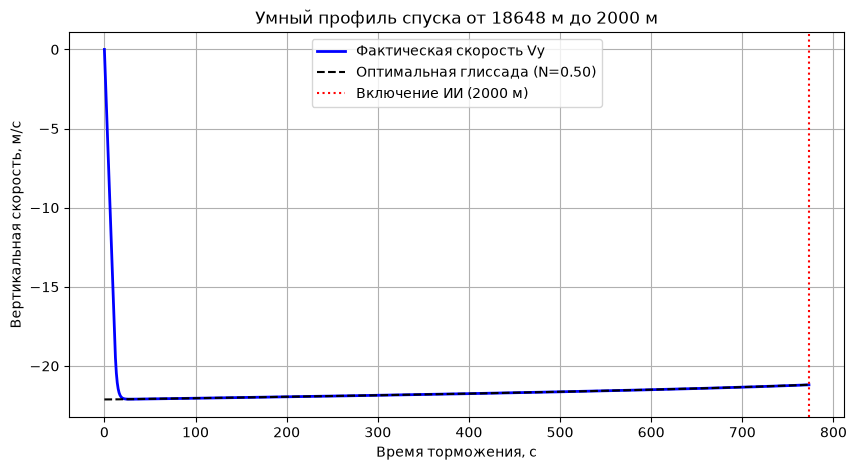

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from skopt import gp_minimize
from skopt.space import Real
import warnings

warnings.filterwarnings("ignore")

# --- КОНСТАНТЫ ---
MU_MOON = 6.67e-11 * 7.3477e22
R_MOON = 1737400.0        
M_INITIAL = 1462.0
M_PROPELLANT_INITIAL = 958.0
DRY_MASS = M_INITIAL - M_PROPELLANT_INITIAL
H_ORBIT = 100000.0        
THRUST = 2930.0     
ISP = 310.0          
G0 = 9.80665            
MASS_FLOW = THRUST / (ISP * G0) 
G_MOON = 1.62

HS_TARGET = 2000.0   
TARGET_VX = 35.0
TARGET_VY = -35.0

# --- 1. АНАЛИТИКА ---
def calculate_doi(H_pdi):
    r_apo = R_MOON + H_ORBIT
    r_peri = R_MOON + H_pdi
    a_ellipse = (r_apo + r_peri) / 2.0
    V_circ = np.sqrt(MU_MOON / r_apo)
    V_apo_ellipse = np.sqrt(MU_MOON * (2.0 / r_apo - 1.0 / a_ellipse))
    Delta_V = V_circ - V_apo_ellipse
    M_start_descent = M_INITIAL * np.exp(-Delta_V / (ISP * G0))
    fuel_doi = M_INITIAL - M_start_descent
    Vx_peri = np.sqrt(MU_MOON * (2.0 / r_peri - 1.0 / a_ellipse))
    return Vx_peri, M_start_descent, fuel_doi

# --- 2. СИМУЛЯТОР ---
def lander_dynamics(t, state, Kp, Vy_start_target, Vy_end, N, H_pdi):
    x, y, vx, vy, m = state
    h_norm = np.clip(y / H_pdi, 0.0, 1.0)
    
    # ИСПРАВЛЕННАЯ ГЛИССАДА: Автопилот сразу требует отрицательную скорость!
    vy_desired = Vy_end + (Vy_start_target - Vy_end) * (h_norm ** N)
    
    ay_desired = Kp * (vy_desired - vy)
    Ty = m * (ay_desired + G_MOON)
    Ty = np.clip(Ty, 0, THRUST)
        
    Tx_max = np.sqrt(max(0, THRUST**2 - Ty**2))
    
    if vx > 0.1:
        Tx = -Tx_max
    else:
        Tx = 0 
        
    ax = Tx / m
    ay = (Ty / m) - G_MOON
    dm_dt = -MASS_FLOW
    
    if m <= DRY_MASS: # Бак пуст
        ax, ay, dm_dt = 0, -G_MOON, 0
    
    return [vx, vy, ax, ay, dm_dt]

def reach_hs(t, state, *args):
    return state[1] - HS_TARGET
reach_hs.terminal = True
reach_hs.direction = -1

# --- 3. ФУНКЦИЯ ПОТЕРЬ ---
def objective(params):
    Kp, Vy_start_target, Vy_end, N, H_pdi = params
    
    Vx0, M0, fuel_doi = calculate_doi(H_pdi)
    initial_state = [0.0, H_pdi, Vx0, 0.0, M0]
    
    sol = solve_ivp(
        lander_dynamics, (0, 1000), initial_state, 
        args=(Kp, Vy_start_target, Vy_end, N, H_pdi),
        events=reach_hs, max_step=2.0
    )
    
    if len(sol.t_events[0]) == 0:
        return 999999.0
        
    vx_final = sol.y[2][-1]
    vy_final = sol.y[3][-1]
    m_final = sol.y[4][-1]
    
    # ЖЕСТКИЙ ШТРАФ ЗА ИСЧЕРПАНИЕ ТОПЛИВА (если осталось меньше 5 кг)
    if m_final <= DRY_MASS + 5.0:
        return 999999.0
    
    total_fuel_consumed = fuel_doi + (M0 - m_final)
    
    # Считаем абсолютную ошибку по модулю (не в квадрате, чтобы не было взрыва градиента)
    error_vx = abs(vx_final - TARGET_VX)
    error_vy = abs(vy_final - TARGET_VY)
    
    # Итоговый loss
    loss = total_fuel_consumed + 500.0 * (error_vx + error_vy)
    return loss

# --- 4. ОПТИМИЗАЦИЯ ---
space = [
    Real(0.05, 0.5, name='Kp'),                 # Ограничили максимальную агрессивность
    Real(-30.0, -5.0, name='Vy_start_target'),  # Целевая скорость падения в самом начале
    Real(-60.0, -20.0, name='Vy_end'),         
    Real(0.5, 2.0, name='N'),                   # Запретили N=3.0, чтобы не висел в воздухе
    Real(10000.0, 20000.0, name='H_pdi')       
]

# НАША ШПАРГАЛКА (Точка, которая гарантированно долетает и не падает)
x0 = [0.1, -10.0, -40.0, 1.0, 15000.0]

print("Запуск УМНОЙ оптимизации... Ожидайте.")
res = gp_minimize(objective, space, x0=x0, n_calls=100, random_state=42, verbose=False)
best_Kp, best_Vy_start, best_Vy_end, best_N, best_H_pdi = res.x

print("\n" + "="*50)
print(" ОПТИМИЗАЦИЯ УСПЕШНО ЗАВЕРШЕНА")
print("="*50)
print(f"Идеальная высота схода с орбиты (H_pdi): {best_H_pdi:.1f} м")
print(f"Коэффициент П-регулятора (Kp): {best_Kp:.4f}")
print(f"Целевая начальная скорость (Vy_start): {best_Vy_start:.2f} м/с")
print(f"Целевая конечная скорость (Vy_end): {best_Vy_end:.2f} м/с")
print(f"Степень кривизны глиссады (N): {best_N:.3f}")

# --- 5. ФИНАЛЬНЫЙ РАСЧЕТ ---
Vx0, M0, fuel_doi = calculate_doi(best_H_pdi)
sol_best = solve_ivp(
    lander_dynamics, (0, 1000), [0.0, best_H_pdi, Vx0, 0.0, M0], 
    args=(best_Kp, best_Vy_start, best_Vy_end, best_N, best_H_pdi),
    events=reach_hs, max_step=1.0
)

t_best, y_best = sol_best.t, sol_best.y[1]
vx_best, vy_best, m_best = sol_best.y[2], sol_best.y[3], sol_best.y[4]
total_best_fuel = fuel_doi + (M0 - m_best[-1])

print(f"\n[Результаты на высоте передачи управления ИИ (2000 м)]")
print(f"Фактическая Vx: {vx_best[-1]:.2f} м/с (Требовалось {TARGET_VX})")
print(f"Фактическая Vy: {vy_best[-1]:.2f} м/с (Требовалось {TARGET_VY})")
print(f"СУММАРНОЕ ТОПЛИВО (Миссия): {total_best_fuel:.2f} кг")
print(f"Остаток топлива для ИИ (ECS-AI): {m_best[-1] - 5000:.2f} кг")

# --- 6. ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(10, 5))
h_norm_plot = np.clip(y_best / best_H_pdi, 0, 1)
vy_desired_plot = best_Vy_end + (best_Vy_start - best_Vy_end) * (h_norm_plot ** best_N)

plt.plot(t_best, vy_best, label="Фактическая скорость Vy", color="blue", linewidth=2)
plt.plot(t_best, vy_desired_plot, label=f"Оптимальная глиссада (N={best_N:.2f})", linestyle="--", color="black")
plt.axvline(t_best[-1], color='red', linestyle=':', label='Включение ИИ (2000 м)')

plt.title(f"Умный профиль спуска от {best_H_pdi:.0f} м до 2000 м")
plt.xlabel("Время торможения, с")
plt.ylabel("Вертикальная скорость, м/с")
plt.legend()
plt.grid()
plt.show()



[Результаты на высоте передачи управления ИИ (2000 м)]
Фактическая Vx: 0.10 м/с (Требовалось 35.0)
Фактическая Vy: -21.19 м/с (Требовалось -35.0)
СУММАРНОЕ ТОПЛИВО (Миссия): 754.03 кг
Остаток топлива для ИИ (ECS-AI): 203.97 кг
Угол наклона тяги к горизонту на высоте 2 км: 23.1 градусов
Отклонение КА от вертикали (Pitch-up maneuver): 66.9 градусов


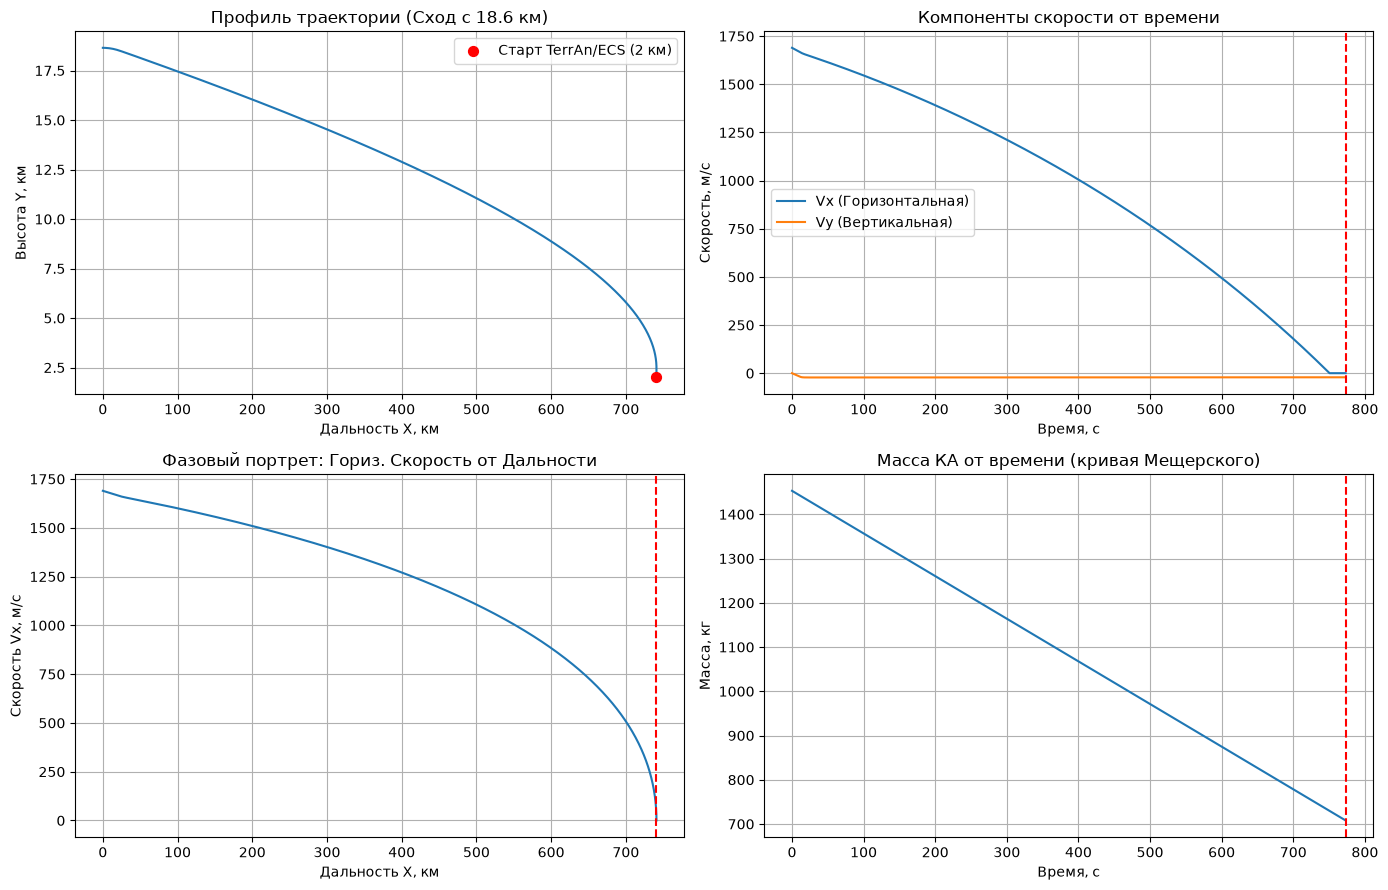

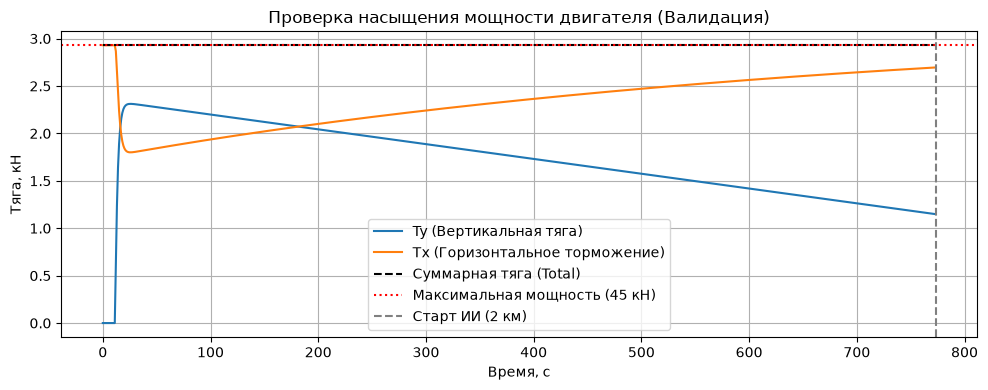

In [9]:
# --- 5. ФИНАЛЬНЫЙ РАСЧЕТ ЛУЧШЕЙ ТРАЕКТОРИИ ---
Vx0, M0, fuel_doi = calculate_doi(best_H_pdi)
sol_best = solve_ivp(
    lander_dynamics, (0, 1000), [0.0, best_H_pdi, Vx0, 0.0, M0], 
    args=(best_Kp, best_Vy_start, best_Vy_end, best_N, best_H_pdi),
    events=reach_hs, max_step=1.0
)

# Извлекаем все массивы
t_best = sol_best.t
x_best = sol_best.y[0]  # <--- Добавили дальность X
y_best = sol_best.y[1]
vx_best = sol_best.y[2]
vy_best = sol_best.y[3]
m_best = sol_best.y[4]

total_best_fuel = fuel_doi + (M0 - m_best[-1])

print(f"\n[Результаты на высоте передачи управления ИИ (2000 м)]")
print(f"Фактическая Vx: {vx_best[-1]:.2f} м/с (Требовалось {TARGET_VX})")
print(f"Фактическая Vy: {vy_best[-1]:.2f} м/с (Требовалось {TARGET_VY})")
print(f"СУММАРНОЕ ТОПЛИВО (Миссия): {total_best_fuel:.2f} кг")
print(f"Остаток топлива для ИИ (ECS-AI): {m_best[-1] - DRY_MASS:.2f} кг")

# --- Вычисление угла наклона КА (тангажа) в точке Hs (индекс -1) ---
# Используем ОПТИМИЗИРОВАННЫЕ параметры для глиссады
h_norm_hs = np.clip(y_best[-1] / best_H_pdi, 0.0, 1.0)
vy_desired_hs = best_Vy_end + (best_Vy_start - best_Vy_end) * (h_norm_hs ** best_N)
ay_desired_hs = best_Kp * (vy_desired_hs - vy_best[-1])

Ty_hs = m_best[-1] * (ay_desired_hs + G_MOON)
Ty_hs = np.clip(Ty_hs, 0, THRUST)
Tx_hs = np.sqrt(max(0, THRUST**2 - Ty_hs**2))

# Вектор скорости направлен вперед, тяга назад. Угол наклона аппарата к горизонту:
pitch_deg = np.degrees(np.arctan2(Ty_hs, Tx_hs))
print(f"Угол наклона тяги к горизонту на высоте 2 км: {pitch_deg:.1f} градусов")
print(f"Отклонение КА от вертикали (Pitch-up maneuver): {90.0 - pitch_deg:.1f} градусов")

# =====================================================================
# --- 6. ВИЗУАЛИЗАЦИЯ (Графики) ---
# =====================================================================

fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# 1. Профиль траектории
axs[0, 0].plot(x_best/1000, y_best/1000)
axs[0, 0].scatter(x_best[-1]/1000, y_best[-1]/1000, color='red', s=50, zorder=5, label='Старт TerrAn/ECS (2 км)')
axs[0, 0].set_title(f"Профиль траектории (Сход с {best_H_pdi/1000:.1f} км)")
axs[0, 0].set_xlabel("Дальность X, км")
axs[0, 0].set_ylabel("Высота Y, км")
axs[0, 0].grid()
axs[0, 0].legend()

# 2. Компоненты скорости
axs[0, 1].plot(t_best, vx_best, label='Vx (Горизонтальная)')
axs[0, 1].plot(t_best, vy_best, label='Vy (Вертикальная)')
axs[0, 1].axvline(t_best[-1], color='red', linestyle='--')
axs[0, 1].set_title("Компоненты скорости от времени")
axs[0, 1].set_xlabel("Время, с")
axs[0, 1].set_ylabel("Скорость, м/с")
axs[0, 1].grid()
axs[0, 1].legend()

# 3. Фазовый портрет
axs[1, 0].plot(x_best/1000, vx_best)
axs[1, 0].axvline(x_best[-1]/1000, color='red', linestyle='--')
axs[1, 0].set_title("Фазовый портрет: Гориз. Скорость от Дальности")
axs[1, 0].set_xlabel("Дальность X, км")
axs[1, 0].set_ylabel("Скорость Vx, м/с")
axs[1, 0].grid()

# 4. Кривая Мещерского
axs[1, 1].plot(t_best, m_best)
axs[1, 1].axvline(t_best[-1], color='red', linestyle='--')
axs[1, 1].set_title("Масса КА от времени (кривая Мещерского)")
axs[1, 1].set_xlabel("Время, с")
axs[1, 1].set_ylabel("Масса, кг")
axs[1, 1].grid()

plt.tight_layout()
plt.show()

# =====================================================================
# --- 7. ВАЛИДАЦИЯ ТЯГИ ДВИГАТЕЛЯ ---
# =====================================================================

Ty_arr = np.zeros_like(t_best)
Tx_arr = np.zeros_like(t_best)

# Пересчитываем Ty и Tx для каждой точки, используя ОПТИМИЗИРОВАННЫЕ параметры
for i in range(len(t_best)):
    y = y_best[i]
    vy = vy_best[i]
    m = m_best[i]
    vx = vx_best[i]
    
    h_norm = np.clip(y / best_H_pdi, 0.0, 1.0)
    vy_desired = best_Vy_end + (best_Vy_start - best_Vy_end) * (h_norm ** best_N)
    ay_desired = best_Kp * (vy_desired - vy)
    
    Ty = m * (ay_desired + G_MOON)
    Ty = np.clip(Ty, 0, THRUST)
    Ty_arr[i] = Ty
    
    if vx > 0.0:
        Tx_arr[i] = np.sqrt(max(0, THRUST**2 - Ty**2))
    else:
        Tx_arr[i] = 0

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(t_best, Ty_arr/1000, label='Ty (Вертикальная тяга)')
ax2.plot(t_best, Tx_arr/1000, label='Tx (Горизонтальное торможение)')
ax2.plot(t_best, np.sqrt(Tx_arr**2 + Ty_arr**2)/1000, 'k--', label='Суммарная тяга (Total)')
ax2.axhline(THRUST/1000, color='r', linestyle=':', label='Максимальная мощность (45 кН)')
ax2.axvline(t_best[-1], color='gray', linestyle='--', label='Старт ИИ (2 км)')

ax2.set_title("Проверка насыщения мощности двигателя (Валидация)")
ax2.set_xlabel("Время, с")
ax2.set_ylabel("Тяга, кН")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()


# для маленнького КА selected code

Запуск УМНОЙ оптимизации... Ожидайте.

 ОПТИМИЗАЦИЯ УСПЕШНО ЗАВЕРШЕНА
Идеальная высота схода с орбиты (H_pdi): 17486.0 м
Коэффициент П-регулятора (Kp): 0.1364
Целевая начальная скорость (Vy_start): -9.82 м/с
Целевая конечная скорость (Vy_end): -39.95 м/с
Степень кривизны глиссады (N): 0.986

[Результаты на высоте передачи управления ИИ (2000 м)]
Фактическая Vx: 35.00 м/с (Требовалось 35.0)
Фактическая Vy: -35.94 м/с (Требовалось -35.0)
СУММАРНОЕ ТОПЛИВО (Миссия): 762.81 кг
Остаток топлива для ИИ (ECS-AI): 195.19 кг
Угол наклона тяги к горизонту на 2 км: 90.0 градусов
Отклонение КА от вертикали (Pitch-up maneuver): 0.0 градусов


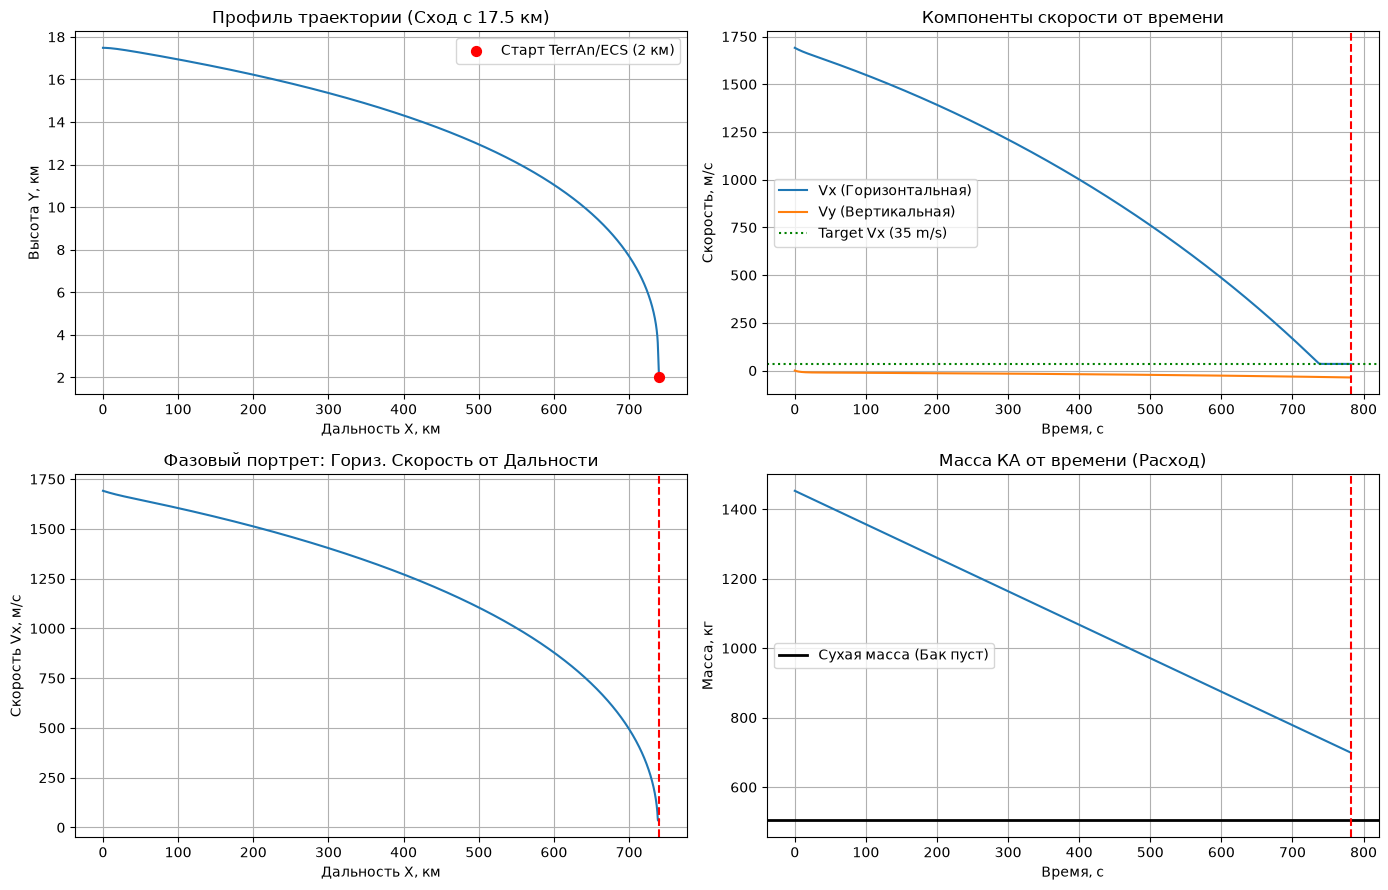

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from skopt import gp_minimize
from skopt.space import Real
import warnings

warnings.filterwarnings("ignore")

# --- КОНСТАНТЫ ---
MU_MOON = 4.9048695e12 # Чуть точнее гравитационный параметр
R_MOON = 1737400.0        
M_INITIAL = 1462.0
M_PROPELLANT_INITIAL = 958.0
DRY_MASS = M_INITIAL - M_PROPELLANT_INITIAL
H_ORBIT = 100000.0        
THRUST = 2930.0     
ISP = 310.0          
G0 = 9.80665            
MASS_FLOW = THRUST / (ISP * G0) 
G_MOON = 1.62

HS_TARGET = 2000.0   
TARGET_VX = 35.0
TARGET_VY = -35.0

# --- 1. АНАЛИТИКА ---
def calculate_doi(H_pdi):
    r_apo = R_MOON + H_ORBIT
    r_peri = R_MOON + H_pdi
    a_ellipse = (r_apo + r_peri) / 2.0
    V_circ = np.sqrt(MU_MOON / r_apo)
    V_apo_ellipse = np.sqrt(MU_MOON * (2.0 / r_apo - 1.0 / a_ellipse))
    Delta_V = V_circ - V_apo_ellipse
    M_start_descent = M_INITIAL * np.exp(-Delta_V / (ISP * G0))
    fuel_doi = M_INITIAL - M_start_descent
    Vx_peri = np.sqrt(MU_MOON * (2.0 / r_peri - 1.0 / a_ellipse))
    return Vx_peri, M_start_descent, fuel_doi

# --- 2. СИМУЛЯТОР ---
def lander_dynamics(t, state, Kp, Vy_start_target, Vy_end, N, H_pdi):
    x, y, vx, vy, m = state
    h_norm = np.clip(y / H_pdi, 0.0, 1.0)
    
    vy_desired = Vy_end + (Vy_start_target - Vy_end) * (h_norm ** N)
    
    ay_desired = Kp * (vy_desired - vy)
    Ty = m * (ay_desired + G_MOON)
    Ty = np.clip(Ty, 0, THRUST)
        
    Tx_max = np.sqrt(max(0, THRUST**2 - Ty**2))
    
    # === НОВАЯ ЛОГИКА ТОРМОЖЕНИЯ (БЕЗ ГРАВИТАЦИОННЫХ ПОТЕРЬ) ===
    if vx > TARGET_VX + 5.0:
        Tx = -Tx_max # Тормозим на максимум
    elif vx > TARGET_VX:
        # Плавное снижение тяги, чтобы не проскочить 35 м/с
        Tx = -Tx_max * ((vx - TARGET_VX) / 5.0) 
    else:
        Tx = 0 # Достигли 35 м/с — перестаем жечь топливо по X! Высвобождаем мощь для Ty.
        
    ax = Tx / m
    ay = (Ty / m) - G_MOON
    dm_dt = -MASS_FLOW
    
    if m <= DRY_MASS: 
        ax, ay, dm_dt = 0, -G_MOON, 0
    
    return [vx, vy, ax, ay, dm_dt]

def reach_hs(t, state, *args):
    return state[1] - HS_TARGET
reach_hs.terminal = True
reach_hs.direction = -1

# --- 3. ФУНКЦИЯ ПОТЕРЬ ---
def objective(params):
    Kp, Vy_start_target, Vy_end, N, H_pdi = params
    
    Vx0, M0, fuel_doi = calculate_doi(H_pdi)
    initial_state = [0.0, H_pdi, Vx0, 0.0, M0]
    
    sol = solve_ivp(
        lander_dynamics, (0, 1500), initial_state, 
        args=(Kp, Vy_start_target, Vy_end, N, H_pdi),
        events=reach_hs, max_step=2.0
    )
    
    if len(sol.t_events[0]) == 0:
        return 999999.0
        
    vx_final = sol.y[2][-1]
    vy_final = sol.y[3][-1]
    m_final = sol.y[4][-1]
    
    if m_final <= DRY_MASS + 5.0:
        return 999999.0
    
    total_fuel_consumed = fuel_doi + (M0 - m_final)
    
    # Штраф за Vx теперь минимален, так как автопилот сам ее держит.
    # Главная задача оптимизатора - идеально попасть в Vy = -35.
    error_vy = abs(vy_final - TARGET_VY)
    
    loss = total_fuel_consumed + 1000.0 * error_vy
    return loss

# --- 4. ОПТИМИЗАЦИЯ ---
space = [
    Real(0.05, 0.5, name='Kp'),                 
    Real(-30.0, 0.0, name='Vy_start_target'),  
    Real(-60.0, -20.0, name='Vy_end'),         
    Real(0.5, 2.5, name='N'),                   
    Real(12000.0, 25000.0, name='H_pdi') # Слабому двигателю может потребоваться тормозить с бОльшей высоты     
]

x0 = [0.1, -10.0, -40.0, 1.0, 18000.0]

print("Запуск УМНОЙ оптимизации... Ожидайте.")
res = gp_minimize(objective, space, x0=x0, n_calls=70, random_state=42, verbose=False)
best_Kp, best_Vy_start, best_Vy_end, best_N, best_H_pdi = res.x

print("\n" + "="*50)
print(" ОПТИМИЗАЦИЯ УСПЕШНО ЗАВЕРШЕНА")
print("="*50)
print(f"Идеальная высота схода с орбиты (H_pdi): {best_H_pdi:.1f} м")
print(f"Коэффициент П-регулятора (Kp): {best_Kp:.4f}")
print(f"Целевая начальная скорость (Vy_start): {best_Vy_start:.2f} м/с")
print(f"Целевая конечная скорость (Vy_end): {best_Vy_end:.2f} м/с")
print(f"Степень кривизны глиссады (N): {best_N:.3f}")

# --- 5. ФИНАЛЬНЫЙ РАСЧЕТ ---
Vx0, M0, fuel_doi = calculate_doi(best_H_pdi)
sol_best = solve_ivp(
    lander_dynamics, (0, 1500), [0.0, best_H_pdi, Vx0, 0.0, M0], 
    args=(best_Kp, best_Vy_start, best_Vy_end, best_N, best_H_pdi),
    events=reach_hs, max_step=1.0
)

t_best, y_best = sol_best.t, sol_best.y[1]
vx_best, vy_best, m_best = sol_best.y[2], sol_best.y[3], sol_best.y[4]
x_best = sol_best.y[0]
total_best_fuel = fuel_doi + (M0 - m_best[-1])

print(f"\n[Результаты на высоте передачи управления ИИ (2000 м)]")
print(f"Фактическая Vx: {vx_best[-1]:.2f} м/с (Требовалось {TARGET_VX})")
print(f"Фактическая Vy: {vy_best[-1]:.2f} м/с (Требовалось {TARGET_VY})")
print(f"СУММАРНОЕ ТОПЛИВО (Миссия): {total_best_fuel:.2f} кг")
print(f"Остаток топлива для ИИ (ECS-AI): {m_best[-1] - DRY_MASS:.2f} кг")

# Расчет угла на высоте 2 км
h_norm_hs = np.clip(y_best[-1] / best_H_pdi, 0.0, 1.0)
vy_desired_hs = best_Vy_end + (best_Vy_start - best_Vy_end) * (h_norm_hs ** best_N)
ay_desired_hs = best_Kp * (vy_desired_hs - vy_best[-1])

Ty_hs = m_best[-1] * (ay_desired_hs + G_MOON)
Ty_hs = np.clip(Ty_hs, 0, THRUST)
Tx_hs = np.sqrt(max(0, THRUST**2 - Ty_hs**2))

if vx_best[-1] > TARGET_VX + 5.0:
    Tx_hs_actual = Tx_hs
elif vx_best[-1] > TARGET_VX:
    Tx_hs_actual = Tx_hs * ((vx_best[-1] - TARGET_VX) / 5.0)
else:
    Tx_hs_actual = 0

pitch_deg = np.degrees(np.arctan2(Ty_hs, Tx_hs_actual))
print(f"Угол наклона тяги к горизонту на 2 км: {pitch_deg:.1f} градусов")
print(f"Отклонение КА от вертикали (Pitch-up maneuver): {90.0 - pitch_deg:.1f} градусов")

# --- 6. ВИЗУАЛИЗАЦИЯ ---
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# 1. Профиль
axs[0, 0].plot(x_best/1000, y_best/1000)
axs[0, 0].scatter(x_best[-1]/1000, y_best[-1]/1000, color='red', s=50, zorder=5, label='Старт TerrAn/ECS (2 км)')
axs[0, 0].set_title(f"Профиль траектории (Сход с {best_H_pdi/1000:.1f} км)")
axs[0, 0].set_xlabel("Дальность X, км")
axs[0, 0].set_ylabel("Высота Y, км")
axs[0, 0].grid()
axs[0, 0].legend()

# 2. Скорости
axs[0, 1].plot(t_best, vx_best, label='Vx (Горизонтальная)')
axs[0, 1].plot(t_best, vy_best, label='Vy (Вертикальная)')
axs[0, 1].axhline(TARGET_VX, color='g', linestyle=':', label='Target Vx (35 m/s)')
axs[0, 1].axvline(t_best[-1], color='red', linestyle='--')
axs[0, 1].set_title("Компоненты скорости от времени")
axs[0, 1].set_xlabel("Время, с")
axs[0, 1].set_ylabel("Скорость, м/с")
axs[0, 1].grid()
axs[0, 1].legend()

# 3. Фазовый портрет
axs[1, 0].plot(x_best/1000, vx_best)
axs[1, 0].axvline(x_best[-1]/1000, color='red', linestyle='--')
axs[1, 0].set_title("Фазовый портрет: Гориз. Скорость от Дальности")
axs[1, 0].set_xlabel("Дальность X, км")
axs[1, 0].set_ylabel("Скорость Vx, м/с")
axs[1, 0].grid()

# 4. Масса
axs[1, 1].plot(t_best, m_best)
axs[1, 1].axhline(DRY_MASS, color='black', linestyle='-', linewidth=2, label='Сухая масса (Бак пуст)')
axs[1, 1].axvline(t_best[-1], color='red', linestyle='--')
axs[1, 1].set_title("Масса КА от времени (Расход)")
axs[1, 1].set_xlabel("Время, с")
axs[1, 1].set_ylabel("Масса, кг")
axs[1, 1].grid()
axs[1, 1].legend()

plt.tight_layout()
plt.show()


# добавим π-регулятор для оси $OX$

Запуск ДВУМЕРНОЙ векторной оптимизации... Ожидайте.

 ОПТИМИЗАЦИЯ УСПЕШНО ЗАВЕРШЕНА
Идеальная высота H_pdi: 27568.0 м
Коэффициент Y (Kp): 0.2988 | Коэффициент X (Kpx): 0.9045
Степень глиссады Y (Ny): 2.813 | Степень глиссады X (Nx): 1.957

[Результаты на высоте передачи управления ИИ (2000 м)]
Фактическая Vx: 35.01 м/с (Требовалось 35.0)
Фактическая Vy: -35.00 м/с (Требовалось -35.0)
СУММАРНОЕ ТОПЛИВО (Миссия): 803.42 кг
Остаток топлива для ИИ (ECS-AI): 154.58 кг
Угол наклона тяги к горизонту на 2 км: 90.3 градусов
Отклонение КА от вертикали (Pitch-up maneuver): -0.3 градусов


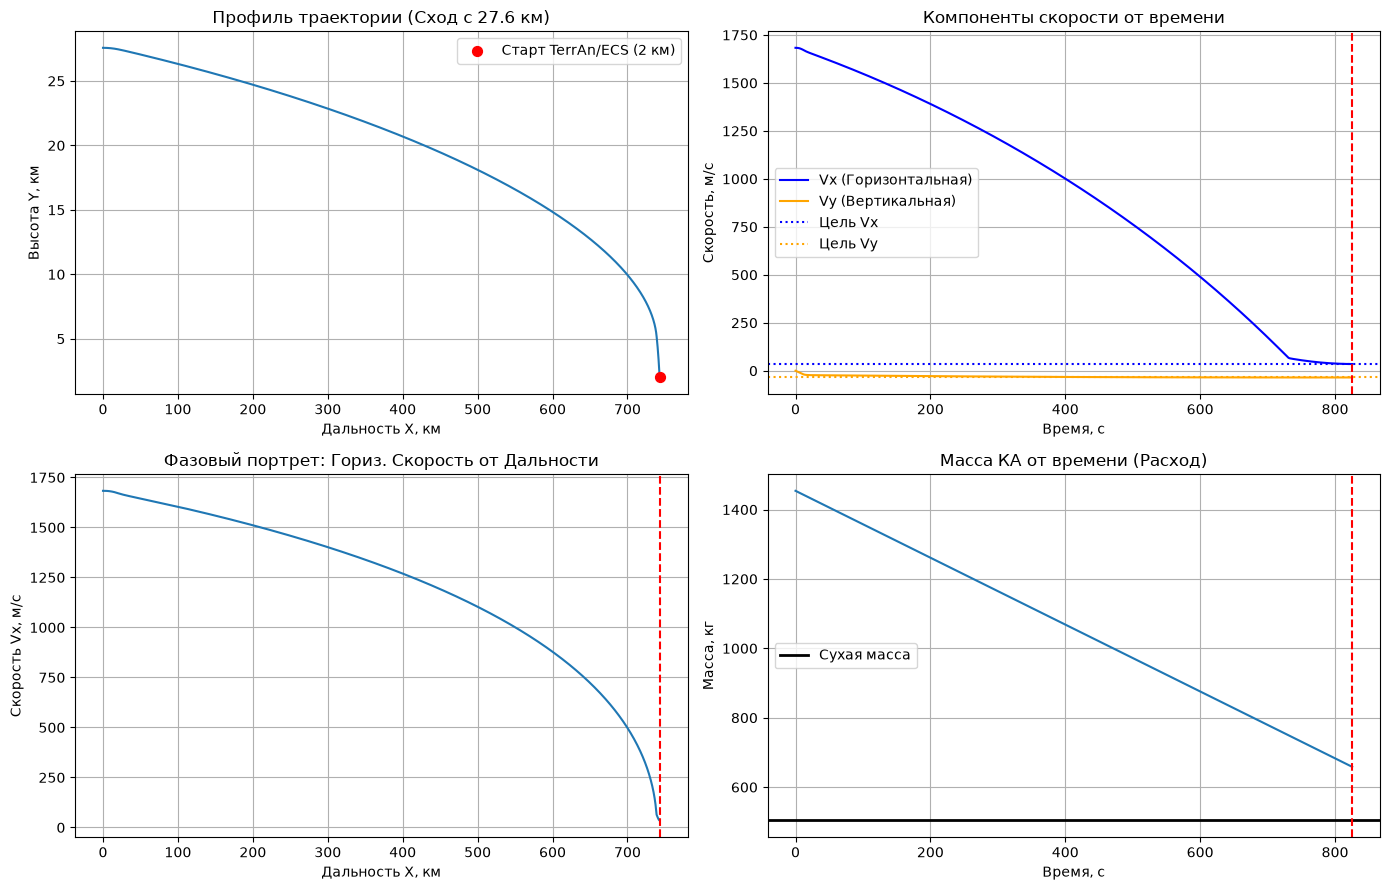

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from skopt import gp_minimize
from skopt.space import Real
import warnings

warnings.filterwarnings("ignore")

# --- КОНСТАНТЫ ---
MU_MOON = 6.67e-11 * 7.3477e22
R_MOON = 1737400.0        
M_INITIAL = 1462.0
M_PROPELLANT_INITIAL = 958.0
DRY_MASS = M_INITIAL - M_PROPELLANT_INITIAL
H_ORBIT = 100000.0        
THRUST = 2930.0     
ISP = 310.0          
G0 = 9.80665            
MASS_FLOW = THRUST / (ISP * G0) 
G_MOON = 1.62

HS_TARGET = 2000.0   
TARGET_VX = 35.0
TARGET_VY = -35.0

# --- 1. АНАЛИТИКА ---
def calculate_doi(H_pdi):
    r_apo = R_MOON + H_ORBIT
    r_peri = R_MOON + H_pdi
    a_ellipse = (r_apo + r_peri) / 2.0
    V_circ = np.sqrt(MU_MOON / r_apo)
    V_apo_ellipse = np.sqrt(MU_MOON * (2.0 / r_apo - 1.0 / a_ellipse))
    Delta_V = V_circ - V_apo_ellipse
    M_start_descent = M_INITIAL * np.exp(-Delta_V / (ISP * G0))
    fuel_doi = M_INITIAL - M_start_descent
    Vx_peri = np.sqrt(MU_MOON * (2.0 / r_peri - 1.0 / a_ellipse))
    return Vx_peri, M_start_descent, fuel_doi

# --- 2. ДВУМЕРНЫЙ СИМУЛЯТОР ---
def lander_dynamics(t, state, Kp, Kpx, Vy_start_target, Ny, Nx, H_pdi, Vx0):
    x, y, vx, vy, m = state
    
    # Прогресс спуска от H_pdi до 2000 м (1.0 на старте, 0.0 у цели)
    s = np.clip((y - HS_TARGET) / (H_pdi - HS_TARGET), 0.0, 1.0)
    
    # Целевые скорости по осям X и Y
    vy_desired = TARGET_VY + (Vy_start_target - TARGET_VY) * (s ** Ny)
    vx_desired = TARGET_VX + (Vx0 - TARGET_VX) * (s ** Nx)
    
    # П-регуляторы запрашивают ускорения
    ay_desired = Kp * (vy_desired - vy)
    ax_desired = Kpx * (vx_desired - vx)
    
    # Требуемая тяга
    Ty_req = m * (ay_desired + G_MOON)
    Tx_req = m * ax_desired
    
    # Балансировка тяги (Приоритет удержанию высоты Ty)
    Ty = np.clip(Ty_req, 0, THRUST)
    max_Tx = np.sqrt(max(0, THRUST**2 - Ty**2))
    
    # Tx_req будет отрицательным (торможение). Ограничиваем его физикой двигателя
    Tx = np.clip(Tx_req, -max_Tx, max_Tx)
        
    ax = Tx / m
    ay = (Ty / m) - G_MOON
    dm_dt = -MASS_FLOW
    
    if m <= DRY_MASS: 
        ax, ay, dm_dt = 0, -G_MOON, 0
    
    return [vx, vy, ax, ay, dm_dt]

def reach_hs(t, state, *args):
    return state[1] - HS_TARGET
reach_hs.terminal = True
reach_hs.direction = -1

# --- 3. ФУНКЦИЯ ПОТЕРЬ ---
def objective(params):
    Kp, Kpx, Vy_start_target, Ny, Nx, H_pdi = params
    
    Vx0, M0, fuel_doi = calculate_doi(H_pdi)
    initial_state = [0.0, H_pdi, Vx0, 0.0, M0]
    
    sol = solve_ivp(
        lander_dynamics, (0, 1500), initial_state, 
        args=(Kp, Kpx, Vy_start_target, Ny, Nx, H_pdi, Vx0),
        events=reach_hs, max_step=2.0
    )
    
    if len(sol.t_events[0]) == 0:
        return 999999.0
        
    vx_final = sol.y[2][-1]
    vy_final = sol.y[3][-1]
    m_final = sol.y[4][-1]
    
    if m_final <= DRY_MASS + 5.0:
        return 999999.0
    
    total_fuel_consumed = fuel_doi + (M0 - m_final)
    
    # Ошибки по скоростям
    error_vx = abs(vx_final - TARGET_VX)
    error_vy = abs(vy_final - TARGET_VY)
    
    # Штрафуем жестко за скорости, чтобы ИИ нашел идеальные кривые
    loss = total_fuel_consumed + 1000.0 * (error_vx + error_vy)
    return loss

# --- 4. ОПТИМИЗАЦИЯ ---
space = [
    Real(0.05, 1.0, name='Kp'),                 # Y-регулятор
    Real(0.05, 1.0, name='Kpx'),                # X-регулятор
    Real(-30.0, 0.0, name='Vy_start_target'),  
    Real(0.2, 3.0, name='Ny'),                  # Изгиб Y-глиссады
    Real(0.2, 3.0, name='Nx'),                  # Изгиб X-глиссады
    Real(15000.0, 30000.0, name='H_pdi')        # Даем больше высоты слабому двигателю!
]

# Шпаргалка (чтобы оптимизатор не блуждал на старте)
x0 = [0.5, 0.5, -10.0, 1.0, 1.0, 20000.0]

print("Запуск ДВУМЕРНОЙ векторной оптимизации... Ожидайте.")
res = gp_minimize(objective, space, x0=x0, n_calls=100, random_state=42, verbose=False)
best_Kp, best_Kpx, best_Vy_start, best_Ny, best_Nx, best_H_pdi = res.x

print("\n" + "="*50)
print(" ОПТИМИЗАЦИЯ УСПЕШНО ЗАВЕРШЕНА")
print("="*50)
print(f"Идеальная высота H_pdi: {best_H_pdi:.1f} м")
print(f"Коэффициент Y (Kp): {best_Kp:.4f} | Коэффициент X (Kpx): {best_Kpx:.4f}")
print(f"Степень глиссады Y (Ny): {best_Ny:.3f} | Степень глиссады X (Nx): {best_Nx:.3f}")

# --- 5. ФИНАЛЬНЫЙ РАСЧЕТ ---
Vx0, M0, fuel_doi = calculate_doi(best_H_pdi)
sol_best = solve_ivp(
    lander_dynamics, (0, 1500), [0.0, best_H_pdi, Vx0, 0.0, M0], 
    args=(best_Kp, best_Kpx, best_Vy_start, best_Ny, best_Nx, best_H_pdi, Vx0),
    events=reach_hs, max_step=1.0
)

t_best, y_best, x_best = sol_best.t, sol_best.y[1], sol_best.y[0]
vx_best, vy_best, m_best = sol_best.y[2], sol_best.y[3], sol_best.y[4]
total_best_fuel = fuel_doi + (M0 - m_best[-1])

print(f"\n[Результаты на высоте передачи управления ИИ (2000 м)]")
print(f"Фактическая Vx: {vx_best[-1]:.2f} м/с (Требовалось {TARGET_VX})")
print(f"Фактическая Vy: {vy_best[-1]:.2f} м/с (Требовалось {TARGET_VY})")
print(f"СУММАРНОЕ ТОПЛИВО (Миссия): {total_best_fuel:.2f} кг")
print(f"Остаток топлива для ИИ (ECS-AI): {m_best[-1] - DRY_MASS:.2f} кг")

# --- Расчет тангажа на высоте 2 км ---
s_hs = 0.0 # Потому что мы точно на 2000 м
vy_desired_hs = TARGET_VY
vx_desired_hs = TARGET_VX

ay_desired_hs = best_Kp * (vy_desired_hs - vy_best[-1])
ax_desired_hs = best_Kpx * (vx_desired_hs - vx_best[-1])

Ty_req_hs = m_best[-1] * (ay_desired_hs + G_MOON)
Ty_hs = np.clip(Ty_req_hs, 0, THRUST)

Tx_req_hs = m_best[-1] * ax_desired_hs
max_Tx_hs = np.sqrt(max(0, THRUST**2 - Ty_hs**2))
Tx_hs = np.clip(Tx_req_hs, -max_Tx_hs, max_Tx_hs)

pitch_deg = np.degrees(np.arctan2(Ty_hs, Tx_hs))
print(f"Угол наклона тяги к горизонту на 2 км: {pitch_deg:.1f} градусов")
print(f"Отклонение КА от вертикали (Pitch-up maneuver): {90.0 - pitch_deg:.1f} градусов")

# --- 6. ВИЗУАЛИЗАЦИЯ ---
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

axs[0, 0].plot(x_best/1000, y_best/1000)
axs[0, 0].scatter(x_best[-1]/1000, y_best[-1]/1000, color='red', s=50, zorder=5, label='Старт TerrAn/ECS (2 км)')
axs[0, 0].set_title(f"Профиль траектории (Сход с {best_H_pdi/1000:.1f} км)")
axs[0, 0].set_xlabel("Дальность X, км")
axs[0, 0].set_ylabel("Высота Y, км")
axs[0, 0].grid()
axs[0, 0].legend()

axs[0, 1].plot(t_best, vx_best, label='Vx (Горизонтальная)', color='blue')
axs[0, 1].plot(t_best, vy_best, label='Vy (Вертикальная)', color='orange')
axs[0, 1].axhline(TARGET_VX, color='blue', linestyle=':', label='Цель Vx')
axs[0, 1].axhline(TARGET_VY, color='orange', linestyle=':', label='Цель Vy')
axs[0, 1].axvline(t_best[-1], color='red', linestyle='--')
axs[0, 1].set_title("Компоненты скорости от времени")
axs[0, 1].set_xlabel("Время, с")
axs[0, 1].set_ylabel("Скорость, м/с")
axs[0, 1].grid()
axs[0, 1].legend()

axs[1, 0].plot(x_best/1000, vx_best)
axs[1, 0].axvline(x_best[-1]/1000, color='red', linestyle='--')
axs[1, 0].set_title("Фазовый портрет: Гориз. Скорость от Дальности")
axs[1, 0].set_xlabel("Дальность X, км")
axs[1, 0].set_ylabel("Скорость Vx, м/с")
axs[1, 0].grid()

axs[1, 1].plot(t_best, m_best)
axs[1, 1].axhline(DRY_MASS, color='black', linestyle='-', linewidth=2, label='Сухая масса')
axs[1, 1].axvline(t_best[-1], color='red', linestyle='--')
axs[1, 1].set_title("Масса КА от времени (Расход)")
axs[1, 1].set_xlabel("Время, с")
axs[1, 1].set_ylabel("Масса, кг")
axs[1, 1].grid()
axs[1, 1].legend()

plt.tight_layout()
plt.show()
